# Evaluasi Otsu, Bradley-Roth, dan Sauvola pada H-DIBCO

**Mata kuliah:** Computer Vision MKA  
**Nama:** Dennita Noor Febianty  
**Topik:** Thresholding citra dokumen dengan iluminasi tidak merata

Notebook ini menguji klaim bahwa thresholding lokal lebih tahan terhadap variasi iluminasi dibandingkan thresholding global. Otsu digunakan sebagai baseline global, sedangkan Bradley-Roth dan Sauvola menjadi metode lokal. Eksperimen memakai H-DIBCO 2016 dan H-DIBCO 2018, tiga tingkat gangguan iluminasi, serta metrik F-measure, PSNR, dan DRD.

Semua data diunduh otomatis dan seluruh eksperimen menggunakan seed tetap. Jalankan **Runtime > Run all** di Google Colab.

## Pertanyaan riset dan hipotesis

1. Apakah Bradley-Roth dan Sauvola menghasilkan F-measure serta PSNR yang lebih tinggi dan DRD yang lebih rendah daripada Otsu pada dokumen H-DIBCO?
2. Apakah keunggulan metode lokal bertambah ketika iluminasi semakin tidak merata?
3. Pada citra seperti apa metode lokal gagal atau tidak lagi unggul?

Hipotesisnya, Otsu tetap kompetitif pada dokumen dengan latar relatif seragam, tetapi performanya turun lebih cepat saat gradien pencahayaan diperkuat. Metode lokal diperkirakan lebih stabil karena threshold dihitung dari lingkungan setiap piksel.

In [1]:
# 1. Import, seed, dan konfigurasi
from pathlib import Path
from urllib.request import urlretrieve
import re
import shutil
import zipfile

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter

SEED = 42
np.random.seed(SEED)

PROJECT_DIR = Path.cwd() / "cvl_thresholding"
ARCHIVE_DIR = PROJECT_DIR / "archives"
DATA_DIR = PROJECT_DIR / "data"
RESULT_DIR = PROJECT_DIR / "results"
for directory in [ARCHIVE_DIR, DATA_DIR, RESULT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

DATASETS = {
    "2016": {
        "original": "https://vc.ee.duth.gr/h-dibco2016/benchmark/DIBCO2016_dataset-original.zip",
        "gt": "https://vc.ee.duth.gr/h-dibco2016/benchmark/DIBCO2016_dataset-GT.zip",
    },
    "2018": {
        "original": "https://vc.ee.duth.gr/h-dibco2018/benchmark/dibco2018_Dataset.zip",
        "gt": "https://vc.ee.duth.gr/h-dibco2018/benchmark/dibco2018-GT.zip",
    },
}

ILLUMINATION_LEVELS = [0.00, 0.25, 0.50]
METHODS = ["Otsu", "Bradley-Roth", "Sauvola"]

print(f"Seed: {SEED}")
print(f"Folder kerja: {PROJECT_DIR}")

Seed: 42
Folder kerja: /workspace/scratch/9dc41ce1c2a7/cvl_thresholding


In [2]:
# 2. Unduh dan ekstrak dataset secara otomatis
def download_and_extract(url, zip_path, extract_dir):
    if not zip_path.exists():
        print(f"Mengunduh {zip_path.name} ...")
        urlretrieve(url, zip_path)
    if not extract_dir.exists() or not any(extract_dir.rglob("*.bmp")):
        extract_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as archive:
            archive.extractall(extract_dir)


for year, sources in DATASETS.items():
    for kind, url in sources.items():
        download_and_extract(
            url,
            ARCHIVE_DIR / f"dibco_{year}_{kind}.zip",
            DATA_DIR / year / kind,
        )

print("Dataset selesai disiapkan.")

Dataset selesai disiapkan.


In [3]:
# 3. Pasangkan citra input dan ground truth
def numeric_id(path):
    match = re.search(r"(\d+)", path.stem)
    if not match:
        raise ValueError(f"ID tidak ditemukan pada {path}")
    return int(match.group(1))


def build_pairs(year):
    originals = {
        numeric_id(path): path
        for path in (DATA_DIR / year / "original").rglob("*.bmp")
    }
    ground_truths = {
        numeric_id(path): path
        for path in (DATA_DIR / year / "gt").rglob("*_gt.bmp")
    }
    common_ids = sorted(set(originals) & set(ground_truths))
    return [
        {"year": year, "image_id": image_id,
         "image_path": originals[image_id], "gt_path": ground_truths[image_id]}
        for image_id in common_ids
    ]


pairs = build_pairs("2016") + build_pairs("2018")
dataset_summary = pd.DataFrame(pairs).groupby("year").size().rename("jumlah_citra")
print(dataset_summary.to_string())
assert len(pairs) == 20, f'Seharusnya ada 20 pasangan, ditemukan {len(pairs)}'


year
2016    10
2018    10


## Implementasi metode

### Otsu
Otsu memilih satu threshold global yang memaksimalkan varians antarkelas. Untuk setiap kandidat threshold, histogram dibagi menjadi kelas gelap dan terang, kemudian dipilih nilai dengan varians antarkelas terbesar.

### Bradley-Roth
Bradley-Roth menghitung rata-rata lokal pada jendela di sekitar piksel. Piksel menjadi foreground jika nilainya lebih rendah daripada rata-rata lokal yang dikurangi proporsi sensitivitas tertentu.

### Sauvola
Sauvola memakai rata-rata lokal dan standar deviasi lokal:

\[
T(x,y)=m(x,y)\left[1+k\left(rac{s(x,y)}{R}-1ight)ight]
\]

Parameter ditetapkan sama untuk semua citra agar perbandingan adil: ukuran jendela 41, sensitivitas Bradley 0,15, \(k=0,2\), dan \(R=128\).

In [4]:
# 4. Implementasi eksplisit Otsu, Bradley-Roth, dan Sauvola
def otsu_threshold(gray):
    hist = np.bincount(gray.ravel(), minlength=256).astype(np.float64)
    probability = hist / hist.sum()
    omega = np.cumsum(probability)
    class_mean = np.cumsum(probability * np.arange(256))
    total_mean = class_mean[-1]

    denominator = omega * (1.0 - omega)
    between_variance = np.zeros(256, dtype=np.float64)
    valid = denominator > 0
    between_variance[valid] = (
        (total_mean * omega[valid] - class_mean[valid]) ** 2
        / denominator[valid]
    )
    return int(np.argmax(between_variance))


def binarize_otsu(gray):
    threshold = otsu_threshold(gray)
    return np.where(gray <= threshold, 0, 255).astype(np.uint8)


def binarize_bradley(gray, window=41, sensitivity=0.15):
    local_mean = uniform_filter(gray.astype(np.float64), size=window, mode="reflect")
    threshold = local_mean * (1.0 - sensitivity)
    return np.where(gray < threshold, 0, 255).astype(np.uint8)


def binarize_sauvola(gray, window=41, k=0.20, R=128.0):
    image = gray.astype(np.float64)
    local_mean = uniform_filter(image, size=window, mode="reflect")
    local_sq_mean = uniform_filter(image * image, size=window, mode="reflect")
    local_std = np.sqrt(np.maximum(local_sq_mean - local_mean * local_mean, 0))
    threshold = local_mean * (1.0 + k * (local_std / R - 1.0))
    return np.where(image < threshold, 0, 255).astype(np.uint8)


METHOD_FUNCTIONS = {
    "Otsu": binarize_otsu,
    "Bradley-Roth": binarize_bradley,
    "Sauvola": binarize_sauvola,
}

print("Ketiga metode berhasil didefinisikan.")

Ketiga metode berhasil didefinisikan.


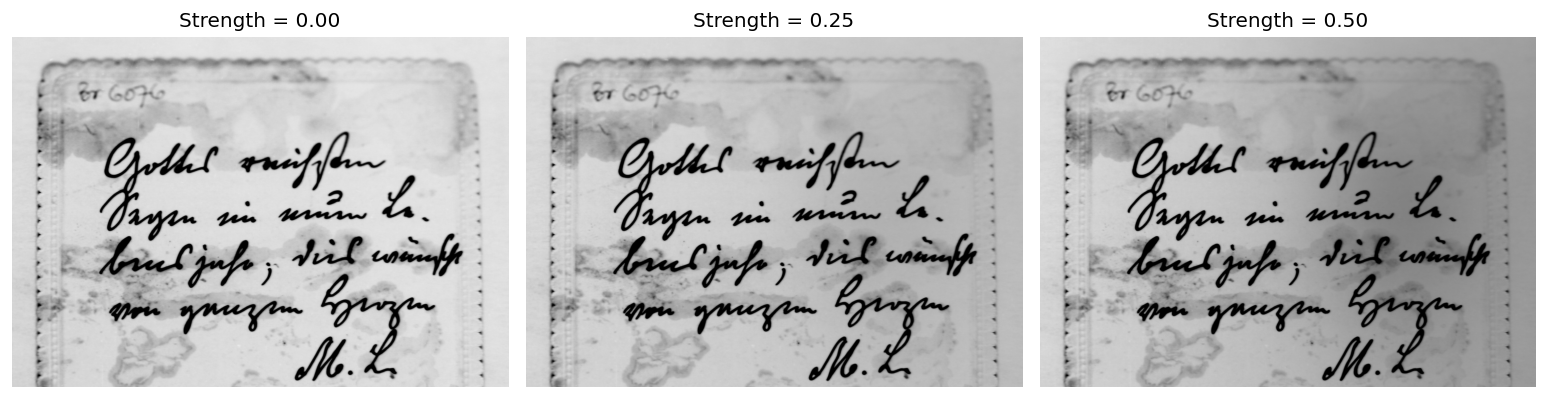

In [5]:
# 5. Gangguan iluminasi tidak merata yang deterministik
def add_uneven_illumination(gray, strength):
    if strength == 0:
        return gray.copy()

    height, width = gray.shape
    x = np.linspace(0.0, 1.0, width, dtype=np.float64)[None, :]
    y = np.linspace(-1.0, 1.0, height, dtype=np.float64)[:, None]

    horizontal_gradient = x
    soft_shadow = np.exp(-((x - 0.72) ** 2 / 0.035 + y ** 2 / 0.65))
    illumination = 1.0 - strength * (0.60 * horizontal_gradient + 0.40 * soft_shadow)

    degraded = gray.astype(np.float64) * illumination
    return np.clip(degraded, 0, 255).astype(np.uint8)


sample_pair = pairs[0]
sample_gray = np.asarray(Image.open(sample_pair["image_path"]).convert("L"))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for axis, level in zip(axes, ILLUMINATION_LEVELS):
    axis.imshow(add_uneven_illumination(sample_gray, level), cmap="gray", vmin=0, vmax=255)
    axis.set_title(f"Strength = {level:.2f}")
    axis.axis("off")
plt.tight_layout()
plt.show()

## Metrik evaluasi

- **F-measure** menggabungkan precision dan recall foreground. Nilai lebih tinggi lebih baik.
- **PSNR** mengukur kesesuaian citra biner dengan ground truth. Nilai lebih tinggi lebih baik.
- **DRD** memberi penalti berdasarkan kesalahan piksel dan konteks tetangganya, lalu membaginya dengan jumlah blok ground truth yang tidak seragam. Nilai lebih rendah lebih baik.

Foreground pada ground truth DIBCO bernilai hitam atau 0.

In [6]:
# 6. Implementasi F-measure, PSNR, dan DRD
def f_measure(prediction, ground_truth):
    pred_fg = prediction == 0
    gt_fg = ground_truth == 0
    tp = np.logical_and(pred_fg, gt_fg).sum()
    fp = np.logical_and(pred_fg, ~gt_fg).sum()
    fn = np.logical_and(~pred_fg, gt_fg).sum()
    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)
    return 2.0 * precision * recall / (precision + recall + 1e-12)


def psnr_binary(prediction, ground_truth):
    mse = np.mean((prediction.astype(np.float64) - ground_truth.astype(np.float64)) ** 2)
    return float("inf") if mse == 0 else 10.0 * np.log10((255.0 ** 2) / mse)


def count_non_uniform_blocks(gt01, block_size=8):
    height, width = gt01.shape
    count = 0
    for row in range(0, height, block_size):
        for col in range(0, width, block_size):
            block = gt01[row:row + block_size, col:col + block_size]
            if block.size and block.min() != block.max():
                count += 1
    return max(count, 1)


def drd(prediction, ground_truth):
    pred01 = (prediction > 0).astype(np.uint8)
    gt01 = (ground_truth > 0).astype(np.uint8)
    mismatch_y, mismatch_x = np.where(pred01 != gt01)
    if len(mismatch_y) == 0:
        return 0.0

    radius = 2
    weights = np.zeros((5, 5), dtype=np.float64)
    for row in range(5):
        for col in range(5):
            if row == radius and col == radius:
                continue
            weights[row, col] = 1.0 / np.sqrt((row - radius) ** 2 + (col - radius) ** 2)
    weights /= weights.sum()

    padded_gt = np.pad(gt01, radius, mode="constant", constant_values=1)
    pred_values = pred01[mismatch_y, mismatch_x]
    distortion = np.zeros(len(mismatch_y), dtype=np.float64)
    for row in range(5):
        for col in range(5):
            if weights[row, col] == 0:
                continue
            neighbor = padded_gt[mismatch_y + row, mismatch_x + col]
            distortion += weights[row, col] * np.abs(
                pred_values.astype(np.int16) - neighbor.astype(np.int16)
            )

    return distortion.sum() / count_non_uniform_blocks(gt01)


print("Metrik evaluasi berhasil didefinisikan.")

Metrik evaluasi berhasil didefinisikan.


In [7]:
# 7. Jalankan seluruh eksperimen
records = []
prediction_cache = {}

for index, pair in enumerate(pairs, start=1):
    gray = np.asarray(Image.open(pair["image_path"]).convert("L"))
    gt = np.asarray(Image.open(pair["gt_path"]).convert("L"))
    gt = np.where(gt < 128, 0, 255).astype(np.uint8)

    for illumination in ILLUMINATION_LEVELS:
        test_image = add_uneven_illumination(gray, illumination)
        for method_name, method_function in METHOD_FUNCTIONS.items():
            prediction = method_function(test_image)
            key = (pair["year"], pair["image_id"], illumination, method_name)
            prediction_cache[key] = prediction
            records.append({
                "year": pair["year"],
                "image_id": pair["image_id"],
                "illumination": illumination,
                "method": method_name,
                "f_measure": f_measure(prediction, gt),
                "psnr": psnr_binary(prediction, gt),
                "drd": drd(prediction, gt),
            })
    print(f"Selesai {index:02d}/{len(pairs)}: {pair['year']}-{pair['image_id']}")

results = pd.DataFrame(records)
results.to_csv(RESULT_DIR / "per_image_metrics.csv", index=False)
print(f"\nJumlah baris hasil: {len(results)}")
print("Eksperimen selesai tanpa error.")

Selesai 01/20: 2016-1
Selesai 02/20: 2016-2
Selesai 03/20: 2016-3
Selesai 04/20: 2016-4
Selesai 05/20: 2016-5
Selesai 06/20: 2016-6
Selesai 07/20: 2016-7
Selesai 08/20: 2016-8
Selesai 09/20: 2016-9
Selesai 10/20: 2016-10
Selesai 11/20: 2018-1
Selesai 12/20: 2018-2
Selesai 13/20: 2018-3
Selesai 14/20: 2018-4
Selesai 15/20: 2018-5
Selesai 16/20: 2018-6
Selesai 17/20: 2018-7
Selesai 18/20: 2018-8
Selesai 19/20: 2018-9
Selesai 20/20: 2018-10

Jumlah baris hasil: 180
Eksperimen selesai tanpa error.


In [8]:
# 8. Ringkasan hasil rata-rata dan standar deviasi
summary = (
    results.groupby(["year", "illumination", "method"])
    .agg(
        f_measure_mean=("f_measure", "mean"),
        f_measure_std=("f_measure", "std"),
        psnr_mean=("psnr", "mean"),
        psnr_std=("psnr", "std"),
        drd_mean=("drd", "mean"),
        drd_std=("drd", "std"),
    )
    .reset_index()
)
summary.to_csv(RESULT_DIR / "summary_metrics.csv", index=False)

display_summary = summary.copy()
numeric_columns = display_summary.select_dtypes(include="number").columns
display_summary[numeric_columns] = display_summary[numeric_columns].round(4)
print(display_summary.to_string(index=False))

year  illumination       method  f_measure_mean  f_measure_std  psnr_mean  psnr_std  drd_mean  drd_std
2016          0.00 Bradley-Roth          0.8444         0.0657    16.6541    2.7017    7.1317   3.3904
2016          0.00         Otsu          0.8659         0.0731    17.7851    4.5003    5.5909   4.5671
2016          0.00      Sauvola          0.8499         0.0782    16.8911    3.2020    6.6147   3.3579
2016          0.25 Bradley-Roth          0.8444         0.0653    16.6452    2.6938    7.1494   3.3988
2016          0.25         Otsu          0.8526         0.0887    17.4598    5.0586    6.6299   6.7392
2016          0.25      Sauvola          0.8499         0.0821    16.9531    3.1969    6.5355   3.3825
2016          0.50 Bradley-Roth          0.8446         0.0648    16.6466    2.6909    7.1414   3.3850
2016          0.50         Otsu          0.4983         0.3262     9.1257    7.9163  127.7686 173.0687
2016          0.50      Sauvola          0.8493         0.0864    17.0026

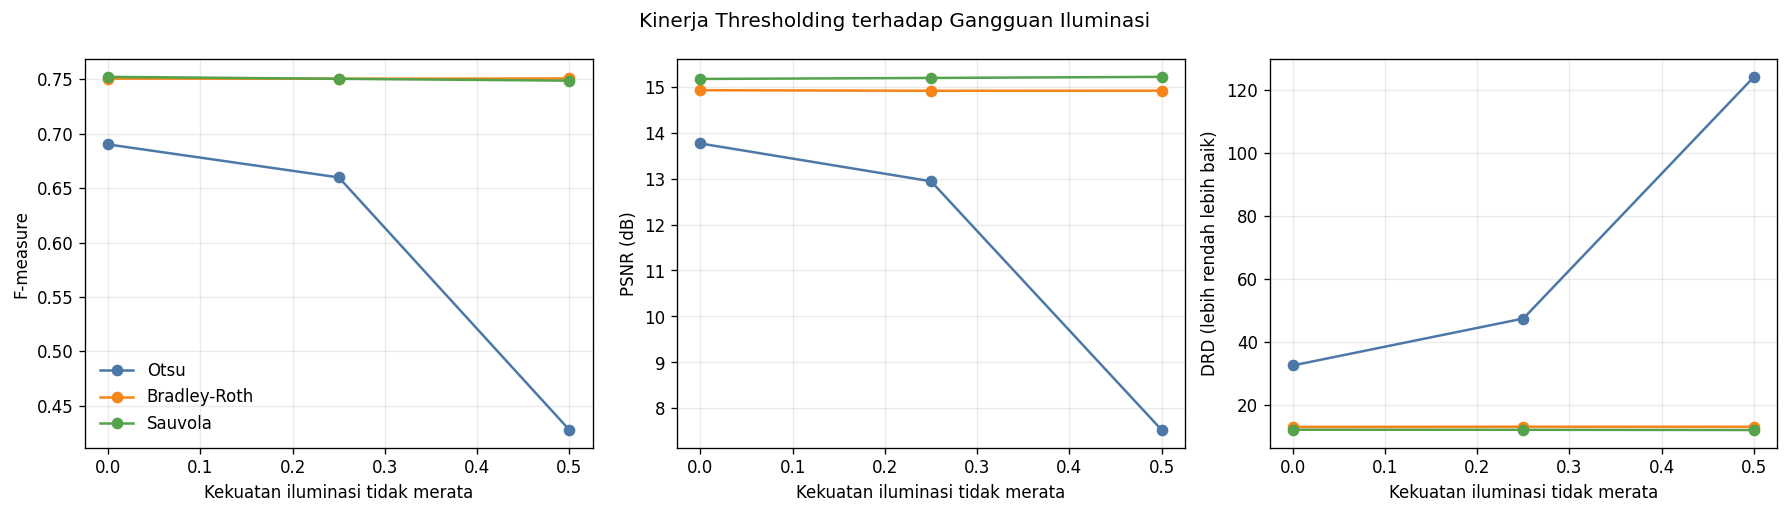

In [9]:
# 9. Grafik utama untuk laporan
overall = (
    results.groupby(["illumination", "method"])[["f_measure", "psnr", "drd"]]
    .mean()
    .reset_index()
)

colors = {"Otsu": "#4C78A8", "Bradley-Roth": "#F58518", "Sauvola": "#54A24B"}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for method in METHODS:
    subset = overall[overall["method"] == method]
    axes[0].plot(subset["illumination"], subset["f_measure"], marker="o", label=method, color=colors[method])
    axes[1].plot(subset["illumination"], subset["psnr"], marker="o", label=method, color=colors[method])
    axes[2].plot(subset["illumination"], subset["drd"], marker="o", label=method, color=colors[method])

axes[0].set_ylabel("F-measure")
axes[1].set_ylabel("PSNR (dB)")
axes[2].set_ylabel("DRD (lebih rendah lebih baik)")
for axis in axes:
    axis.set_xlabel("Kekuatan iluminasi tidak merata")
    axis.grid(alpha=0.25)
axes[0].legend(frameon=False)
fig.suptitle("Kinerja Thresholding terhadap Gangguan Iluminasi")
plt.tight_layout()
figure_path = RESULT_DIR / "figure_performance.png"
plt.savefig(figure_path, dpi=200, bbox_inches="tight")
plt.show()

In [10]:
# 10. Selisih metode lokal terhadap baseline Otsu
pivot = results.pivot_table(
    index=["year", "image_id", "illumination"],
    columns="method",
    values="f_measure",
).reset_index()
pivot["delta_bradley_vs_otsu"] = pivot["Bradley-Roth"] - pivot["Otsu"]
pivot["delta_sauvola_vs_otsu"] = pivot["Sauvola"] - pivot["Otsu"]

delta_summary = (
    pivot.groupby("illumination")[["delta_bradley_vs_otsu", "delta_sauvola_vs_otsu"]]
    .agg(["mean", "median", lambda x: (x > 0).mean()])
)
delta_summary.columns = ["_".join([a, "win_rate" if b == "<lambda_0>" else b]) for a, b in delta_summary.columns]
print(delta_summary.round(4).to_string())

              delta_bradley_vs_otsu_mean  delta_bradley_vs_otsu_median  delta_bradley_vs_otsu_win_rate  delta_sauvola_vs_otsu_mean  delta_sauvola_vs_otsu_median  delta_sauvola_vs_otsu_win_rate
illumination                                                                                                                                                                                    
0.00                              0.0605                        0.0272                            0.65                      0.0621                        0.0338                            0.70
0.25                              0.0907                        0.0439                            0.65                      0.0907                        0.0542                            0.65
0.50                              0.3232                        0.3136                            0.80                      0.3212                        0.3116                            0.80


Kasus terbaik:
method
year                         2016
image_id                        2
illumination                  0.5
Bradley-Roth             0.787435
Otsu                     0.084068
Sauvola                   0.84351
delta_bradley_vs_otsu    0.703368
delta_sauvola_vs_otsu    0.759443

Kasus terburuk:
method
year                         2018
image_id                       10
illumination                  0.0
Bradley-Roth             0.339291
Otsu                     0.732904
Sauvola                  0.188178
delta_bradley_vs_otsu   -0.393613
delta_sauvola_vs_otsu   -0.544726


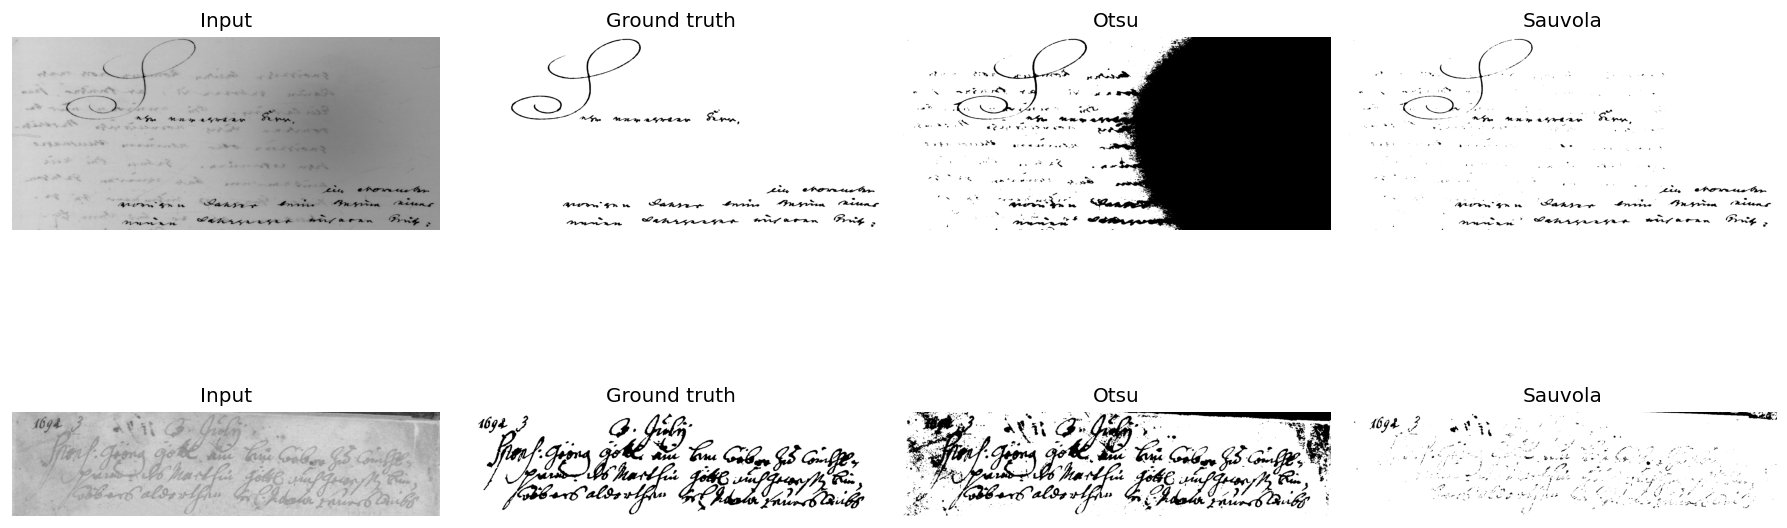

In [11]:
# 11. Visualisasi kasus keberhasilan terbesar dan failure case Sauvola
best_row = pivot.loc[pivot["delta_sauvola_vs_otsu"].idxmax()]
worst_row = pivot.loc[pivot["delta_sauvola_vs_otsu"].idxmin()]

def get_pair(year, image_id):
    return next(p for p in pairs if p["year"] == str(year) and p["image_id"] == int(image_id))


def plot_case(row, row_index, axes, label):
    pair = get_pair(row["year"], row["image_id"])
    gray = np.asarray(Image.open(pair["image_path"]).convert("L"))
    gt = np.asarray(Image.open(pair["gt_path"]).convert("L"))
    test_image = add_uneven_illumination(gray, float(row["illumination"]))

    images = [
        test_image,
        gt,
        prediction_cache[(str(row["year"]), int(row["image_id"]), float(row["illumination"]), "Otsu")],
        prediction_cache[(str(row["year"]), int(row["image_id"]), float(row["illumination"]), "Sauvola")],
    ]
    titles = ["Input", "Ground truth", "Otsu", "Sauvola"]
    for col, (image, title) in enumerate(zip(images, titles)):
        axes[row_index, col].imshow(image, cmap="gray", vmin=0, vmax=255)
        axes[row_index, col].set_title(title)
        axes[row_index, col].axis("off")
    axes[row_index, 0].set_ylabel(
        f"{label}\n{row['year']}-{int(row['image_id'])}, s={row['illumination']:.2f}\n"
        f"ΔF={row['delta_sauvola_vs_otsu']:+.3f}"
    )


fig, axes = plt.subplots(2, 4, figsize=(15, 7))
plot_case(best_row, 0, axes, "Sauvola unggul")
plot_case(worst_row, 1, axes, "Failure case")
plt.tight_layout()
failure_path = RESULT_DIR / "figure_failure_cases.png"
plt.savefig(failure_path, dpi=200, bbox_inches="tight")
plt.show()

print("Kasus terbaik:")
print(best_row.to_string())
print("\nKasus terburuk:")
print(worst_row.to_string())

In [12]:
# 12. Ringkasan otomatis untuk mendukung kesimpulan laporan
best_by_condition = (
    overall.sort_values(["illumination", "f_measure"], ascending=[True, False])
    .groupby("illumination")
    .first()[["method", "f_measure", "psnr", "drd"]]
)
print("Metode dengan F-measure tertinggi pada setiap kondisi:")
print(best_by_condition.round(4).to_string())

print("\nBerkas hasil yang dibuat:")
for path in sorted(RESULT_DIR.iterdir()):
    print("-", path.name)

Metode dengan F-measure tertinggi pada setiap kondisi:
                    method  f_measure     psnr      drd
illumination                                           
0.00               Sauvola     0.7523  15.1667  12.0858
0.25          Bradley-Roth     0.7506  14.9094  13.0382
0.50          Bradley-Roth     0.7508  14.9111  13.0288

Berkas hasil yang dibuat:
- figure_failure_cases.png
- figure_performance.png
- per_image_metrics.csv
- summary_metrics.csv


## Interpretasi

Kesimpulan akhir harus mengikuti tabel dan grafik keluaran notebook. Perhatikan tiga hal ketika membaca hasil:

1. Metode terbaik ditentukan terutama dari F-measure, dengan PSNR dan DRD sebagai pemeriksaan konsistensi.
2. Selisih terhadap Otsu menunjukkan apakah metode lokal benar-benar memberi manfaat, bukan hanya memiliki nilai absolut tinggi.
3. Failure case memperlihatkan kondisi ketika threshold lokal terlalu sensitif terhadap tekstur latar atau ketika threshold global justru sudah cukup memisahkan teks dan kertas.

Notebook menggunakan implementasi yang sama untuk kedua edisi dan tidak melakukan tuning per citra. Karena itu, eksperimen menguji generalisasi parameter tetap, bukan mencari skor maksimum untuk setiap gambar.

## Referensi

1. N. Otsu, “A Threshold Selection Method from Gray-Level Histograms,” *IEEE Transactions on Systems, Man, and Cybernetics*, vol. 9, no. 1, pp. 62-66, 1979.
2. D. Bradley and G. Roth, “Adaptive Thresholding Using the Integral Image,” *Journal of Graphics Tools*, vol. 12, no. 2, pp. 13-21, 2007.
3. J. Sauvola and M. Pietikäinen, “Adaptive Document Image Binarization,” *Pattern Recognition*, vol. 33, no. 2, pp. 225-236, 2000.
4. H. Lu, A. C. Kot, and Y. Q. Shi, “Distance-Reciprocal Distortion Measure for Binary Document Images,” *IEEE Signal Processing Letters*, vol. 11, no. 2, pp. 228-231, 2004.
5. H-DIBCO 2016 benchmark, https://vc.ee.duth.gr/h-dibco2016/benchmark/
6. H-DIBCO 2018 benchmark, https://vc.ee.duth.gr/h-dibco2018/benchmark/